# IIR Filter Design and Trade-offs

This notebook explores several classical IIR filter families and the trade-offs involved in their design.

Butterworth, Chebyshev Type I, Chebyshev Type II, and elliptic filters are examined through their frequency responses, filter orders, and time-domain behavior.

## Objective

The objectives of this notebook are to:

- Understand the main characteristics of Butterworth, Chebyshev, and elliptic IIR filters.
- Observe how filter order affects the frequency response.
- Observe how passband and stopband ripple can be traded for a sharper transition.
- Compare different IIR filter families under the same filter specifications.
- Understand why filter design is a trade-off rather than a single optimization problem.

## Theory

IIR filter families provide different frequency-response characteristics by allowing different forms of ripple and transition behavior.

### Butterworth

The Butterworth filter has a maximally flat magnitude response in the passband.

It provides a smooth response without intentional passband or stopband ripple.

### Chebyshev Type I

Chebyshev Type I filters allow ripple in the passband in exchange for a sharper transition from passband to stopband.

The parameter $R_p$ specifies the maximum passband ripple in decibels.

### Chebyshev Type II

Chebyshev Type II filters have a monotonic passband and allow ripple in the stopband.

The parameter $R_s$ specifies the minimum stopband attenuation in decibels.

### Elliptic

Elliptic filters allow ripple in both the passband and stopband.

This allows a very sharp transition for a given filter order, at the cost of ripple in both regions.

### Filter Specifications

A filter can also be designed from frequency-domain requirements rather than by directly choosing its order.

Typical specifications include:

- Passband edge frequency $f_p$
- Stopband edge frequency $f_s$
- Maximum passband loss $A_p$
- Minimum stopband attenuation $A_s$

The required minimum filter order depends on the selected filter family.

### Frequency Response

The magnitude response in decibels is

$$
H_{\mathrm{dB}}(f) = 20\log_{10}|H(f)|
$$

The transition region lies between the passband and stopband edges.

## Experiment 1: Effect of Butterworth Filter Order

Design several Butterworth low-pass filters with the same cutoff frequency but different orders.

Observe how increasing the order changes the transition between the passband and stopband.

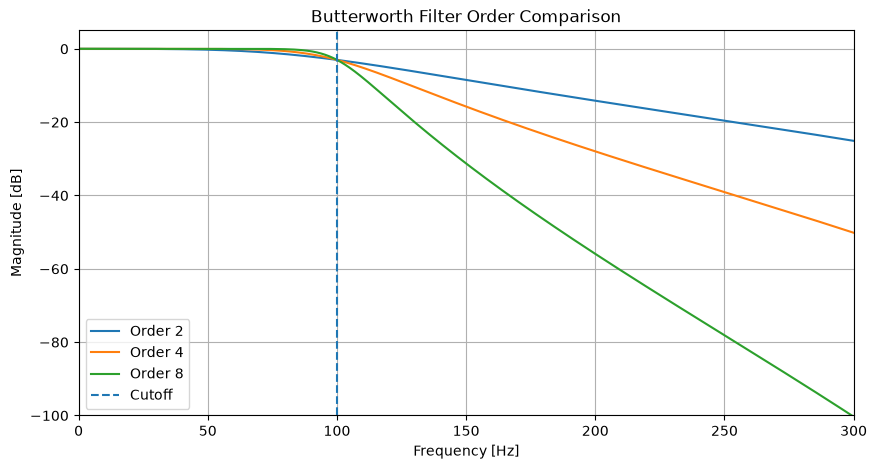

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Sampling frequency
fs = 1000  # Hz

# Frequency range for plotting
f_plot = np.linspace(0, 400, 4000)

# Common cutoff frequency
cutoff = 100  # Hz

# Filter orders
orders = [2, 4, 8]

plt.figure(figsize=(10, 5))

for order in orders:
    b, a = signal.butter(
        N=order,
        Wn=cutoff,
        btype="lowpass",
        fs=fs
    )

    f, h = signal.freqz(
        b,
        a,
        worN=f_plot,
        fs=fs
    )

    magnitude_db = 20 * np.log10(
        np.maximum(np.abs(h), 1e-12)
    )

    plt.plot(
        f,
        magnitude_db,
        label=f"Order {order}"
    )

plt.axvline(
    cutoff,
    linestyle="--",
    label="Cutoff"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Butterworth Filter Order Comparison")
plt.xlim(0, 300)
plt.ylim(-100, 5)
plt.grid()
plt.legend()
plt.show()

### Observation

- As the order increases, transition gets sharper and steeper.
- As the order increases, attenuation above the cutoff frequency pass through the filter in a higher percentage.
- The passband does not develop any visible ripple in applied orders.

## Experiment 2: Chebyshev Type I and Passband Ripple

Keep the filter order and cutoff frequency fixed while changing the allowed passband ripple.

Observe how allowing more ripple affects the transition from passband to stopband.

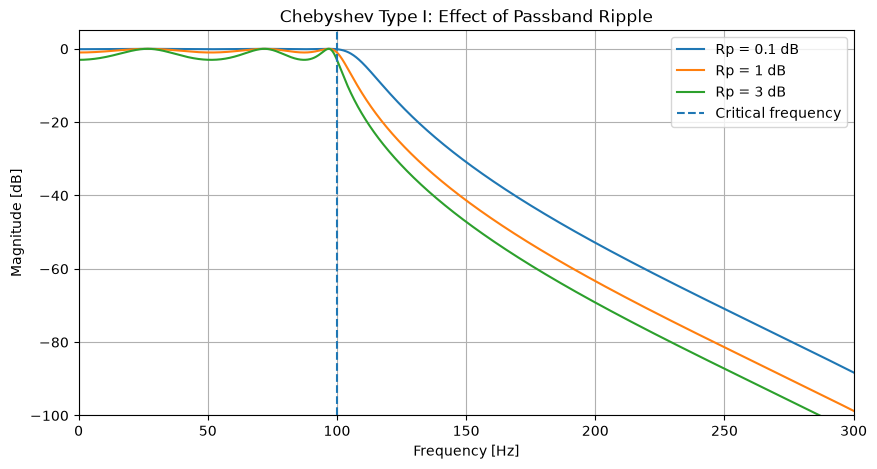

In [3]:
order = 6
rp_values = [0.1, 1, 3]  # dB

plt.figure(figsize=(10, 5))

for rp in rp_values:
    b, a = signal.cheby1(
        N=order,
        rp=rp,
        Wn=cutoff,
        btype="lowpass",
        fs=fs
    )

    f, h = signal.freqz(
        b,
        a,
        worN=f_plot,
        fs=fs
    )

    magnitude_db = 20 * np.log10(
        np.maximum(np.abs(h), 1e-12)
    )

    plt.plot(
        f,
        magnitude_db,
        label=f"Rp = {rp} dB"
    )

plt.axvline(
    cutoff,
    linestyle="--",
    label="Critical frequency"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Chebyshev Type I: Effect of Passband Ripple")
plt.xlim(0, 300)
plt.ylim(-100, 5)
plt.grid()
plt.legend()
plt.show()

### Observation

- The ripple appears at smaller frequencies than cutoff frequency.
- When the allowed ripple increases, sharpness of attenuation around cutoff freq. also increases. 
- Passband smoothness is being sacrificed in order to obtain the sharper transition.

## Experiment 3: Chebyshev Type II and Stopband Ripple

Keep the filter order and cutoff frequency fixed while changing the required stopband attenuation.

Observe how the stopband behavior changes as the attenuation requirement is increased.

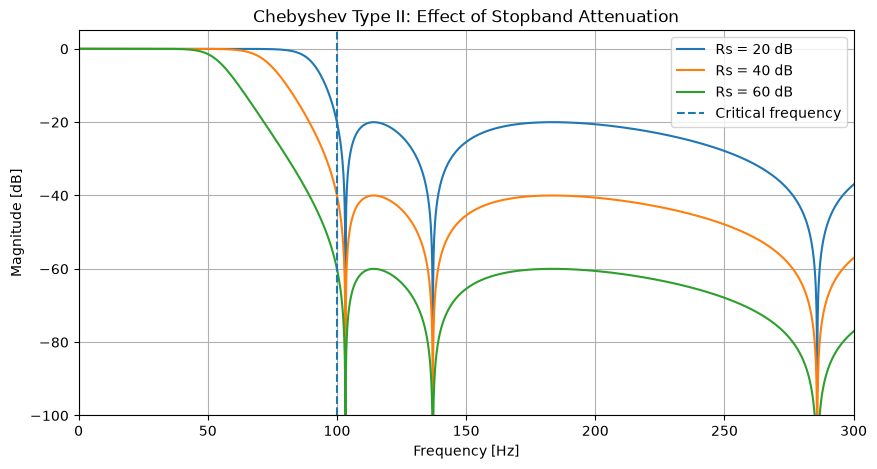

In [4]:
order = 6
rs_values = [20, 40, 60]  # dB

plt.figure(figsize=(10, 5))

for rs in rs_values:
    b, a = signal.cheby2(
        N=order,
        rs=rs,
        Wn=cutoff,
        btype="lowpass",
        fs=fs
    )

    f, h = signal.freqz(
        b,
        a,
        worN=f_plot,
        fs=fs
    )

    magnitude_db = 20 * np.log10(
        np.maximum(np.abs(h), 1e-12)
    )

    plt.plot(
        f,
        magnitude_db,
        label=f"Rs = {rs} dB"
    )

plt.axvline(
    cutoff,
    linestyle="--",
    label="Critical frequency"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Chebyshev Type II: Effect of Stopband Attenuation")
plt.xlim(0, 300)
plt.ylim(-100, 5)
plt.grid()
plt.legend()
plt.show()

### Observation

- This time the ripple appears at bandstop region.
- Increasing the required stopband attenuation shifts initial attenuation point to the left and the stopband ripples become less steep due to increased attenuation.
- Unlike that of Chebyshev 1 filter, Chebyshev 2 filter causes ripples at bandstop region.

## Experiment 4: Comparing IIR Filter Families

Compare Butterworth, Chebyshev Type I, Chebyshev Type II, and elliptic filters using the same nominal order and cutoff frequency.

The purpose is to observe how the four filter families distribute ripple and transition sharpness differently.

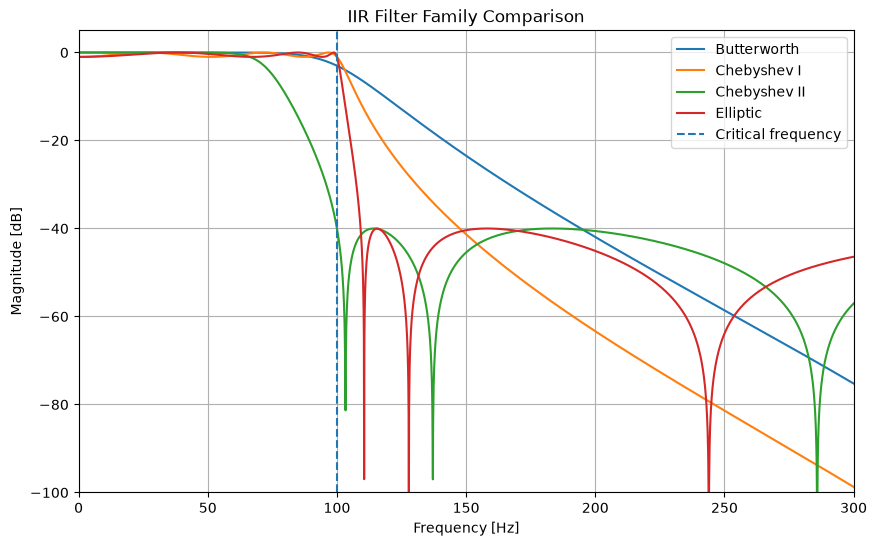

In [5]:
order = 6

filters = {
    "Butterworth": signal.butter(
        N=order,
        Wn=cutoff,
        btype="lowpass",
        fs=fs
    ),
    
    "Chebyshev I": signal.cheby1(
        N=order,
        rp=1,
        Wn=cutoff,
        btype="lowpass",
        fs=fs
    ),
    
    "Chebyshev II": signal.cheby2(
        N=order,
        rs=40,
        Wn=cutoff,
        btype="lowpass",
        fs=fs
    ),
    
    "Elliptic": signal.ellip(
        N=order,
        rp=1,
        rs=40,
        Wn=cutoff,
        btype="lowpass",
        fs=fs
    )
}

plt.figure(figsize=(10, 6))

for name, (b, a) in filters.items():
    f, h = signal.freqz(
        b,
        a,
        worN=f_plot,
        fs=fs
    )

    magnitude_db = 20 * np.log10(
        np.maximum(np.abs(h), 1e-12)
    )

    plt.plot(
        f,
        magnitude_db,
        label=name
    )

plt.axvline(
    cutoff,
    linestyle="--",
    label="Critical frequency"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("IIR Filter Family Comparison")
plt.xlim(0, 300)
plt.ylim(-100, 5)
plt.grid()
plt.legend()
plt.show()

### Observation

- Chebyshev 1 and elliptic filters have passband ripple.
- Chebyshev 2 and elliptic filters have stopband ripple.
- Elliptic filter response transitions most sharply.
- Butterworth response is the smoothest.

## Experiment 5: Minimum Filter Order for the Same Specifications

Instead of choosing the filter order manually, define the required filter performance first.

Use the same passband and stopband specifications for all filter families:

- Passband edge: 100 Hz
- Stopband edge: 140 Hz
- Maximum passband loss: 1 dB
- Minimum stopband attenuation: 50 dB

Determine the minimum filter order required by each filter family.

In [6]:
# Filter specifications
fp = 100       # Passband edge [Hz]
fs_stop = 140  # Stopband edge [Hz]

gpass = 1      # Maximum passband loss [dB]
gstop = 50     # Minimum stopband attenuation [dB]

# Minimum orders
butter_order, butter_wn = signal.buttord(
    wp=fp,
    ws=fs_stop,
    gpass=gpass,
    gstop=gstop,
    fs=fs
)

cheby1_order, cheby1_wn = signal.cheb1ord(
    wp=fp,
    ws=fs_stop,
    gpass=gpass,
    gstop=gstop,
    fs=fs
)

cheby2_order, cheby2_wn = signal.cheb2ord(
    wp=fp,
    ws=fs_stop,
    gpass=gpass,
    gstop=gstop,
    fs=fs
)

ellip_order, ellip_wn = signal.ellipord(
    wp=fp,
    ws=fs_stop,
    gpass=gpass,
    gstop=gstop,
    fs=fs
)

print(f"Butterworth order : {butter_order}")
print(f"Chebyshev I order : {cheby1_order}")
print(f"Chebyshev II order: {cheby2_order}")
print(f"Elliptic order    : {ellip_order}")

Butterworth order : 18
Chebyshev I order : 8
Chebyshev II order: 8
Elliptic order    : 5


### Observation

- Butterworth requires the most number of orders, chebyshev filters require the same amount and elliptic requires the least.
- Chebyshev 1-2 and elliptic filter families satisfy the same specifications with fewer stages.
- There exists a trade-off between band smoothness and engineering efficiency.
- Reducing the filter order might be practically useful to reduce the costs in a project.

## Experiment 6: Step Response and Time-Domain Behavior

A sharper frequency response can affect the time-domain behavior of a filter.

Apply the filters designed with the same specifications to a step signal and compare their responses.

This experiment is intended to reveal differences such as overshoot and ringing.

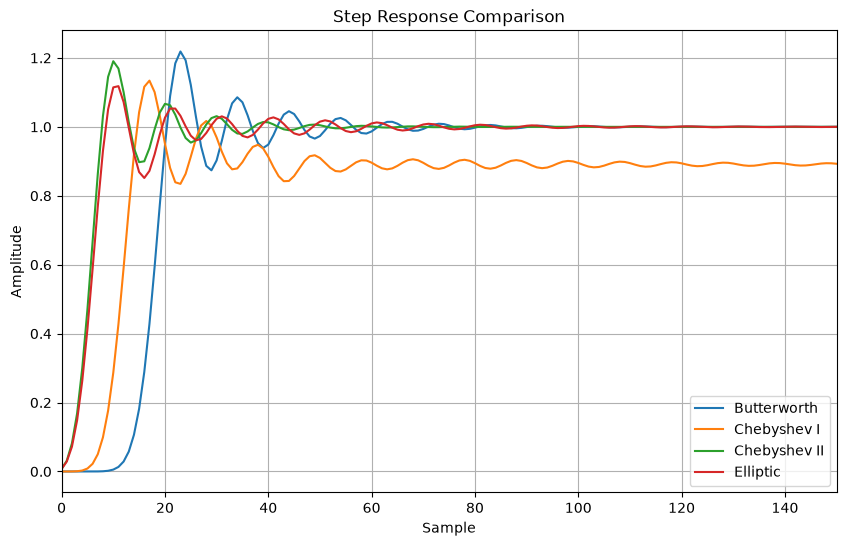

In [7]:
# Design filters using the minimum orders from the previous experiment

b_butter, a_butter = signal.butter(
    butter_order,
    butter_wn,
    btype="lowpass",
    fs=fs
)

b_cheby1, a_cheby1 = signal.cheby1(
    cheby1_order,
    gpass,
    cheby1_wn,
    btype="lowpass",
    fs=fs
)

b_cheby2, a_cheby2 = signal.cheby2(
    cheby2_order,
    gstop,
    cheby2_wn,
    btype="lowpass",
    fs=fs
)

b_ellip, a_ellip = signal.ellip(
    ellip_order,
    gpass,
    gstop,
    ellip_wn,
    btype="lowpass",
    fs=fs
)

# Step signal
n = np.arange(500)
step = np.ones_like(n, dtype=float)

responses = {
    "Butterworth": signal.lfilter(b_butter, a_butter, step),
    "Chebyshev I": signal.lfilter(b_cheby1, a_cheby1, step),
    "Chebyshev II": signal.lfilter(b_cheby2, a_cheby2, step),
    "Elliptic": signal.lfilter(b_ellip, a_ellip, step)
}

plt.figure(figsize=(10, 6))

for name, response in responses.items():
    plt.plot(
        n,
        response,
        label=name
    )

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Step Response Comparison")
plt.xlim(0, 150)
plt.grid()
plt.legend()
plt.show()

### Observation

- Chebyshev 1 filter approaches a slightly lower final value than the others.
- Butterworth and chebyshev 2 responses show more visible overshoot.
- All responses exhibit ringing but chebyshev 2 and elliptic responses exhibit it more than the others.
- The filters with sharper and more selective frequency responses can exhibit more pronounced overshoot and ringing in the time domain.
- Frequency-domain experiments reveal the frequency-selective behavior of different filter families, while time-domain experiments reveal some of the associated costs, such as overshoot and ringing.

## Key Takeaways

- Different IIR filter families achieve different frequency-response characteristics by allowing different types of ripple and transition behavior.
- Increasing filter order generally produces a sharper transition between the passband and stopband.
- Butterworth filters provide a smooth, ripple-free passband, while Chebyshev and elliptic filters trade ripple for sharper transitions.
- For the same passband and stopband specifications, different filter families can require significantly different filter orders.
- A sharper frequency response can be accompanied by stronger time-domain effects such as overshoot and ringing.
- IIR filter design therefore involves trade-offs between transition sharpness, ripple, filter order, attenuation, and time-domain behavior.

## Next Step

The next notebook will investigate numerical stability in IIR filters, especially the problems that can arise in high-order implementations and the use of second-order sections (SOS) to improve numerical robustness.